   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
STEP 1 — Restore from Drive
Mounted at /drive
GPU: Tesla T4
  ✓ Restored /content/yolo_dataset
  ✓ Restored /content/yolo_dataset_baseline

STEP 2 — Re-split 60/20/20

  [density_v2]  missing=0
  Split  Class             Count
  --------------------------------
  train  warehouse          2523
  train  non_warehouse       821
  val    warehouse           841
  val    non_warehouse       274
  test   warehouse           841
  test   non_warehouse       274

  [baseline_global]  missing=0
  Split  Class             Count
  --------------------------------
  train  warehouse          2523
  train  non_wareho

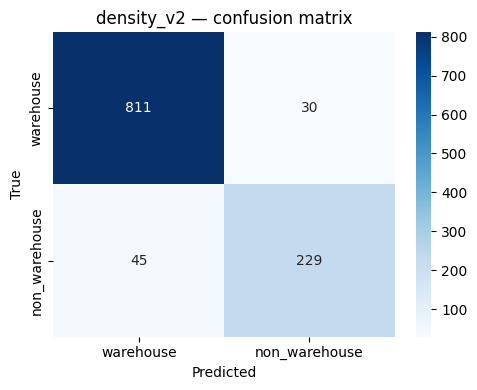


  [density_v2] Classification Report:
               precision    recall  f1-score   support

    warehouse       0.95      0.96      0.96       841
non_warehouse       0.88      0.84      0.86       274

     accuracy                           0.93      1115
    macro avg       0.92      0.90      0.91      1115
 weighted avg       0.93      0.93      0.93      1115



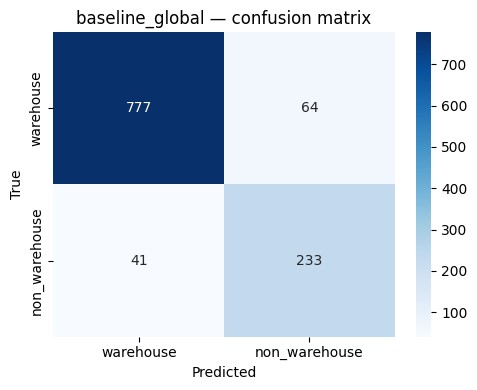


  [baseline_global] Classification Report:
               precision    recall  f1-score   support

    warehouse       0.95      0.92      0.94       841
non_warehouse       0.78      0.85      0.82       274

     accuracy                           0.91      1115
    macro avg       0.87      0.89      0.88      1115
 weighted avg       0.91      0.91      0.91      1115


STEP 7 — Training curves


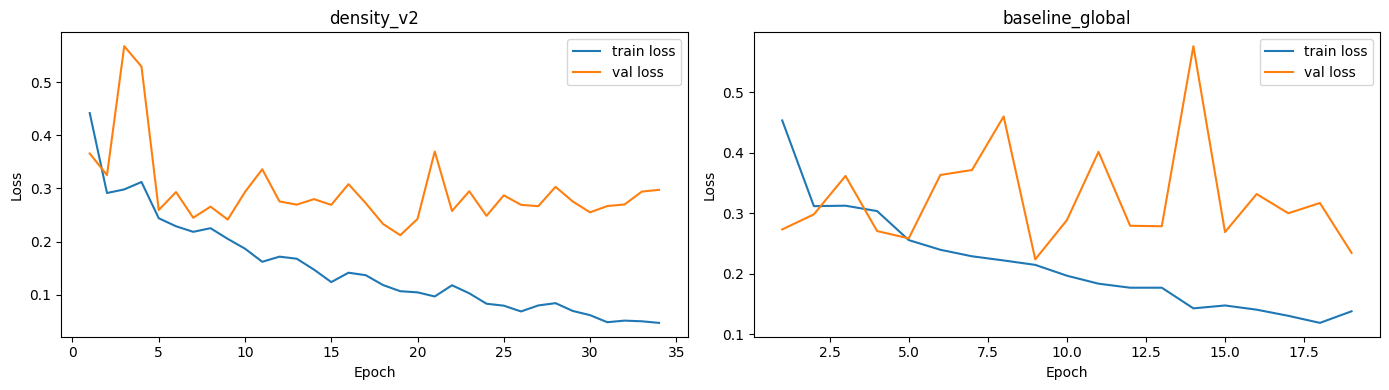


STEP 8 — Save to Drive
  [density_v2]  saved → /drive/MyDrive/yolo_dataset
  [baseline_global]  saved → /drive/MyDrive/yolo_dataset_baseline
  [density_v2]  weights → /drive/MyDrive/yolo_weights_v2/warehouse_v2_v2_best.pt
  [baseline_global]  weights → /drive/MyDrive/yolo_weights_v2/warehouse_baseline_v2_best.pt

✅  Done.


In [1]:
# ============================================================
#  YOLO Retraining  —  from Drive  (Step 6 onwards)
#  Changes vs previous run:
#    1. Split 60 / 20 / 20  (more val/test data)
#    2. Aug both pos + neg in train
#    3. dropout=0.5, weight_decay=1e-3
#    4. augment=True (YOLO built-in aug as extra regularization)
#    5. Absolute project path (fix nested runs/ bug)
# ============================================================

!pip install ultralytics -q

import os, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from ultralytics import YOLO
from google.colab import drive
import torch

# ── Config ──────────────────────────────────────────────────
RANDOM_STATE = 42
SPLIT_RATIOS = (0.60, 0.20, 0.20)   # changed from 70/15/15
CLASS_NAMES  = ["warehouse", "non_warehouse"]
# YOLO alphabetical: non_warehouse=0, warehouse=1

STRATEGIES = {
    "density_v2": {
        "dataset_root": "/content/yolo_dataset",
        "run_name":     "warehouse_v2_v2",
    },
    "baseline_global": {
        "dataset_root": "/content/yolo_dataset_baseline",
        "run_name":     "warehouse_baseline_v2",
    },
}

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# ════════════════════════════════════════════════════════════
#  STEP 1 — Mount Drive & Restore
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 1 — Restore from Drive")
print("=" * 60)

drive.mount("/drive")
print(f"GPU: {torch.cuda.get_device_name(0)}")

for name, cfg in STRATEGIES.items():
    folder   = Path(cfg["dataset_root"]).name
    src      = f"/drive/MyDrive/{folder}"
    dst      = cfg["dataset_root"]
    if os.path.exists(src):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print(f"  ✓ Restored {dst}")
    else:
        raise FileNotFoundError(f"Not found on Drive: {src}")


# ════════════════════════════════════════════════════════════
#  STEP 2 — Re-split 60 / 20 / 20 using manifest.csv
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 2 — Re-split 60/20/20")
print("=" * 60)

def resplit(dataset_root, strategy_name):
    manifest_path = os.path.join(dataset_root, "manifest.csv")
    master = pd.read_csv(manifest_path)

    # Keep only successfully downloaded originals (no aug files)
    master = master[
        master["downloaded_ok"] == True
    ].copy().reset_index(drop=True)

    # Re-split stratified
    train_df, tmp_df = train_test_split(
        master, test_size=(SPLIT_RATIOS[1] + SPLIT_RATIOS[2]),
        stratify=master["yolo_class"], random_state=RANDOM_STATE,
    )
    val_ratio_adj = SPLIT_RATIOS[1] / (SPLIT_RATIOS[1] + SPLIT_RATIOS[2])
    val_df, test_df = train_test_split(
        tmp_df, test_size=(1 - val_ratio_adj),
        stratify=tmp_df["yolo_class"], random_state=RANDOM_STATE,
    )
    for df, sp in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
        master.loc[df.index, "new_split"] = sp

    # Rebuild folder structure
    tmp_root = dataset_root + "_tmp"
    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            Path(tmp_root, split, cls).mkdir(parents=True, exist_ok=True)

    # Copy images to new structure (original files only)
    missing = 0
    for _, row in master.iterrows():
        # Find image in old location
        old_path = None
        for sp in ["train", "val", "test"]:
            p = Path(dataset_root) / sp / row["yolo_label"] / row["img_file"]
            if p.exists():
                old_path = p
                break
        if old_path is None:
            missing += 1
            continue
        new_path = Path(tmp_root) / row["new_split"] / row["yolo_label"] / row["img_file"]
        shutil.copy2(old_path, new_path)

    # Copy yaml
    shutil.copy2(
        os.path.join(dataset_root, "dataset.yaml"),
        os.path.join(tmp_root, "dataset.yaml")
    )

    # Replace old dataset with new
    shutil.rmtree(dataset_root)
    shutil.move(tmp_root, dataset_root)

    # Save updated manifest
    master["split"] = master["new_split"]
    master.drop(columns=["new_split"]).to_csv(manifest_path, index=False)

    print(f"\n  [{strategy_name}]  missing={missing}")
    print(f"  {'Split':5s}  {'Class':15s}  {'Count':>6s}")
    print(f"  {'-'*32}")
    for sp in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            n = len(list((Path(dataset_root) / sp / cls).glob("*.png")))
            print(f"  {sp:5s}  {cls:15s}  {n:6d}")

    return master


for name, cfg in STRATEGIES.items():
    cfg["master"] = resplit(cfg["dataset_root"], name)


# ════════════════════════════════════════════════════════════
#  STEP 3 — Augment  (pos + neg in train)
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 3 — Augment train/non_warehouse")
print("=" * 60)

def aug_flip_h(img):     return img.transpose(Image.FLIP_LEFT_RIGHT)
def aug_flip_v(img):     return img.transpose(Image.FLIP_TOP_BOTTOM)
def aug_rot90(img):      return img.rotate(90)
def aug_brightness(img): return ImageEnhance.Brightness(img).enhance(random.uniform(0.80, 1.20))
def aug_contrast(img):   return ImageEnhance.Contrast(img).enhance(random.uniform(0.80, 1.20))

# neg only ×2 to balance with pos
NEG_COMBOS = [
    [aug_flip_h,  aug_brightness],
    [aug_rot90,   aug_contrast],
]


def augment_train(dataset_root, label):
    cls_dir   = Path(dataset_root) / "train" / "non_warehouse"
    for p in cls_dir.glob("*_aug*.png"):
        p.unlink()
    originals = list(cls_dir.glob("*.png"))
    aug_count = 0
    for img_path in originals:
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            continue
        for i, combo in enumerate(NEG_COMBOS):
            aug_img = img
            for t in combo:
                aug_img = t(aug_img)
            aug_img.save(cls_dir / f"{img_path.stem}_aug{i:02d}.png")
            aug_count += 1
    print(f"  [{label}] neg aug → {aug_count:,} files")
    for cls in CLASS_NAMES:
        n = len(list((Path(dataset_root) / "train" / cls).glob("*.png")))
        print(f"    train / {cls:15s}  →  {n:5d}")


for name, cfg in STRATEGIES.items():
    augment_train(cfg["dataset_root"], name)


# ════════════════════════════════════════════════════════════
#  STEP 4 — Train
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 4 — Training")
print("=" * 60)

for name, cfg in STRATEGIES.items():
    print(f"\n  ── [{name}] ─────────────────────────────────────")
    model = YOLO("yolov8s-cls.pt")
    model.train(
        data         = cfg["dataset_root"],
        epochs       = 50,
        imgsz        = 640,
        batch        = 32,
        dropout      = 0.5,        # ↑ from 0.3
        lr0          = 1e-3,
        weight_decay = 1e-3,       # ↑ from 1e-4
        patience     = 10,
        augment      = True,       # YOLO built-in aug as extra regularization
        workers      = 2,
        project      = "/content/runs/classify",   # absolute path (fix nested bug)
        name         = cfg["run_name"],
        exist_ok     = True,
        verbose      = True,
    )
    cfg["best_weights"] = f"/content/runs/classify/{cfg['run_name']}/weights/best.pt"
    print(f"  [{name}]  best → {cfg['best_weights']}")


# ════════════════════════════════════════════════════════════
#  STEP 5 — Test Set Evaluation
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5 — Test set evaluation")
print("=" * 60)

eval_results = {}
for name, cfg in STRATEGIES.items():
    model   = YOLO(cfg["best_weights"])
    metrics = model.val(
        data=cfg["dataset_root"], split="test",
        imgsz=640, batch=32, workers=2, verbose=False,
    )
    eval_results[name] = {"top1_acc": metrics.top1, "top5_acc": metrics.top5}
    print(f"  [{name}]  top1={metrics.top1:.4f}  top5={metrics.top5:.4f}")

print("\n  === Comparison ===")
print(pd.DataFrame(eval_results).T.to_string())


# ════════════════════════════════════════════════════════════
#  STEP 6 — Confusion Matrix + Classification Report
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 6 — Confusion matrix")
print("=" * 60)

def evaluate_model(weights_path, data_root, model_name):
    model = YOLO(weights_path)
    test_pos = list((Path(data_root) / "test" / "warehouse").glob("*.png"))
    test_neg = list((Path(data_root) / "test" / "non_warehouse").glob("*.png"))
    all_imgs    = test_pos + test_neg
    true_labels = [1] * len(test_pos) + [0] * len(test_neg)
    pred_labels = [int(model(str(p), verbose=False)[0].probs.top1) for p in all_imgs]

    cm = confusion_matrix(true_labels, pred_labels, labels=[1, 0])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["warehouse", "non_warehouse"],
                yticklabels=["warehouse", "non_warehouse"], ax=ax)
    ax.set_title(f"{model_name} — confusion matrix")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout(); plt.show()

    print(f"\n  [{model_name}] Classification Report:")
    print(classification_report(
        true_labels, pred_labels,
        labels=[1, 0], target_names=["warehouse", "non_warehouse"],
    ))
    return true_labels, pred_labels


for name, cfg in STRATEGIES.items():
    evaluate_model(cfg["best_weights"], cfg["dataset_root"], name)


# ════════════════════════════════════════════════════════════
#  STEP 7 — Training Curves
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 7 — Training curves")
print("=" * 60)

fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(7 * len(STRATEGIES), 4))
for ax, (name, cfg) in zip(axes, STRATEGIES.items()):
    csv_path = f"/content/runs/classify/{cfg['run_name']}/results.csv"
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    ax.plot(df["epoch"], df["train/loss"], label="train loss")
    ax.plot(df["epoch"], df["val/loss"],   label="val loss")
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend()
plt.tight_layout(); plt.show()


# ════════════════════════════════════════════════════════════
#  STEP 8 — Save back to Drive
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 8 — Save to Drive")
print("=" * 60)

for name, cfg in STRATEGIES.items():
    folder    = Path(cfg["dataset_root"]).name
    drive_dst = f"/drive/MyDrive/{folder}"
    if os.path.exists(drive_dst):
        shutil.rmtree(drive_dst)
    shutil.copytree(cfg["dataset_root"], drive_dst)
    print(f"  [{name}]  saved → {drive_dst}")

# Save model weights to Drive
weights_drive = "/drive/MyDrive/yolo_weights_v2"
os.makedirs(weights_drive, exist_ok=True)
for name, cfg in STRATEGIES.items():
    dst = os.path.join(weights_drive, f"{cfg['run_name']}_best.pt")
    shutil.copy2(cfg["best_weights"], dst)
    print(f"  [{name}]  weights → {dst}")

print("\n✅  Done.")